In [81]:
!pip install statsmodels

In [82]:
import statsmodels.api as sm

In [83]:
help(sm.GLM)

Help on class GLM in module statsmodels.genmod.generalized_linear_model:

class GLM(statsmodels.base.model.LikelihoodModel)
 |  GLM(
 |      endog,
 |      exog,
 |      family=None,
 |      offset=None,
 |      exposure=None,
 |      freq_weights=None,
 |      var_weights=None,
 |      missing='none',
 |      **kwargs
 |  )
 |
 |  Generalized Linear Models
 |
 |  GLM inherits from statsmodels.base.model.LikelihoodModel
 |
 |  Parameters
 |  ----------
 |  endog : array_like
 |      1d array of endogenous response variable.  This array can be 1d or 2d.
 |      Binomial family models accept a 2d array with two columns. If
 |      supplied, each observation is expected to be [success, failure].
 |  exog : array_like
 |      A nobs x k array where `nobs` is the number of observations and `k`
 |      is the number of regressors. An intercept is not included by default
 |      and should be added by the user (models specified using a formula
 |      include an intercept by default). See `st

# Math & Stat - Excercise Session 7 / Matemáticas y estadísticas - Sesión de ejercicios 7 / Matemática e estatística - Sessão de exercícios 7

EN: Using the cheat sheets inside the directory __reference_documentation_, solve the following exercises.

ES: Usando las hojas de trucos dentro del directorio __reference_documentation_, resuelve los siguientes ejercicios.

PT: Usando as folhas de dicas dentro do diretório __reference_documentation_, resolva os seguintes exercícios.



### Requisitos

In [84]:
!pip install pandas matplotlib scipy scikit-learn

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from scipy.cluster.vq import kmeans,vq
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import numpy as np

In [86]:
df = pd.read_csv('./datasets/UN.csv')

---
### 1. EN: Fill missing values with the median using Fillna. 
### 1. ES: Rellena valores faltantes con la mediana usando fillna.
### 1. PT: Preencha os valores faltantes com a mediana usando fillna.

In [87]:
df

,country,region,tfr,contraception,educationMale,educationFemale,lifeMale,lifeFemale,infantMortality,GDPperCapita,economicActivityMale,economicActivityFemale,illiteracyMale,illiteracyFemale
0,Afghanistan,Asia,6.90,NaN,NaN,NaN,45.0,46.0,154.0,2848.0,87.5,7.2,52.800,85.000
1,Albania,Europe,2.60,NaN,NaN,NaN,68.0,74.0,32.0,863.0,NaN,NaN,NaN,NaN
2,Algeria,Africa,3.81,52.0,11.1,9.9,67.5,70.3,44.0,1531.0,76.4,7.8,26.100,51.000
3,American.Samoa,Asia,NaN,NaN,NaN,NaN,68.0,73.0,11.0,NaN,58.8,42.4,0.264,0.360
4,Andorra,Europe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,Western.Sahara,Africa,3.98,NaN,NaN,NaN,59.8,63.1,64.0,NaN,NaN,NaN,NaN,NaN
203,Yemen,Asia,7.60,7.0,NaN,NaN,57.4,58.4,80.0,732.0,80.6,1.9,32.406,69.552
204,Yugoslavia,Europe,1.80,NaN,NaN,NaN,69.8,75.3,19.0,1487.0,NaN,NaN,1.782,9.072
205,Zambia,Africa,5.49,25.0,7.9,6.8,42.2,43.7,103.0,382.0,NaN,NaN,14.400,28.700


In [88]:
df = df.fillna(df.median(numeric_only=True))

---
### 2. EN: Standard scale all numerical data using StandardScaler (from sklearn.preprocessing import StandardScaler)
### 2. ES: Escalar todos los datos numéricos usando StandardScaler (from sklearn.preprocessing import StandardScaler)
### 2. PT: Escalar todos os dados numéricos usando StandardScaler (de sklearn.preprocessing import StandardScaler)

In [89]:
columnas_numericas = df.describe().columns
columnas_numericas

Index(['tfr', 'contraception', 'educationMale', 'educationFemale', 'lifeMale',
       'lifeFemale', 'infantMortality', 'GDPperCapita', 'economicActivityMale',
       'economicActivityFemale', 'illiteracyMale', 'illiteracyFemale'],
      dtype='object')

In [90]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])

In [91]:
# Recomendado para scripts automaticos de limpieza de datos! 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
for col in df.describe().columns:
    print(col)
    try:
        df[[col]] = scaler.fit_transform(df[[col]])
    except:
        print("error variable:",col)

tfr
contraception
educationMale
educationFemale
lifeMale
lifeFemale
infantMortality
GDPperCapita
economicActivityMale
economicActivityFemale
illiteracyMale
illiteracyFemale


### 3. EN: Create a cluster with Euclidean distance and represent it with a denogram with lifeMale, lifeFemale, infantMortality and GDPperCapita, how many clusters should we do?
### 3. ES: Crear un cluster con distancia euclideanay representarlo con un denograma con lifeMale, lifeFemale, infantMortality y GDPperCapita,  ¿cuantos clusters debemos hacer?
### 3. PT: Crie um cluster com distância euclidiana e represente-o com um denograma com lifeMale, lifeFemale, infantMortality e GDPperCapita, quantos clusters devemos fazer?


In [92]:
#Code

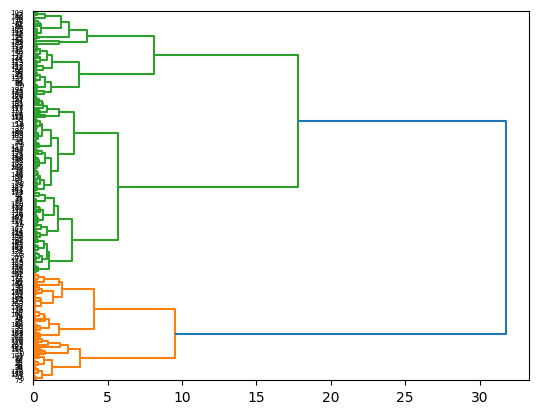

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


linkage_data = linkage(df[['lifeMale', 'lifeFemale', 'infantMortality', 'GDPperCapita']],
                       method='ward', metric='euclidean')
dendrogram(linkage_data, orientation='right')
plt.show()

### 4. EN: Repeat the steps done in class for cluster analysis with Hierarchical Cluster with all linkage methods. methods = ['single', 'complete', 'average', 'weighted', 'centroid','ward'] and then respond the question, which method seems to be more stable and provide better clusters? 

### 4. ES: Repita los pasos realizados en clase para el análisis de clústeres con clústeres jerárquicos con todos los métodos de vinculación. methods = ['single', 'complete', 'average', 'weighted', 'centroid','ward'] y luego responda a la pregunta, ¿qué método parece ser más estable y proporcionar mejores clústeres? 

### 4. PT: Repita as etapas feitas na classe para análise de cluster com Cluster Hierárquico com todos os métodos de ligação. métodos = ['single', 'complete', 'average', 'weighted', 'centroid','ward'] e então responda à pergunta, qual método parece ser mais estável e fornecer melhores clusters? 


Method:  single


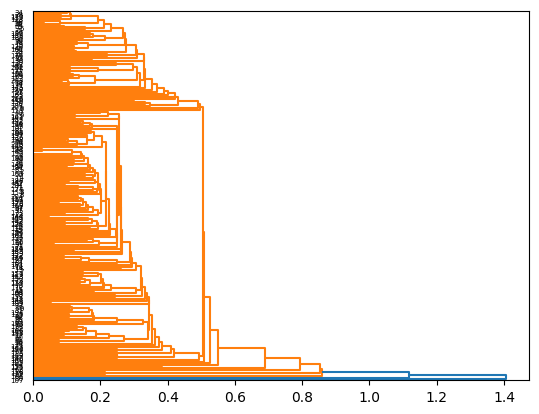

Method:  complete


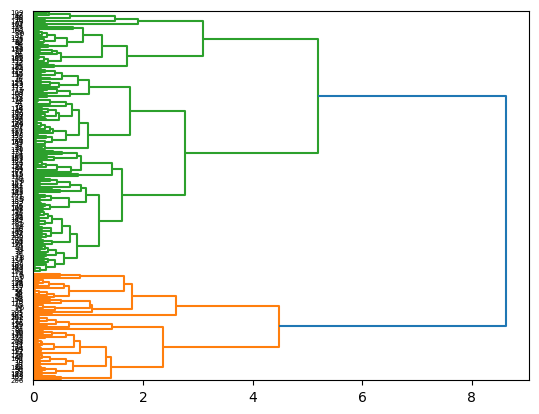

Method:  average


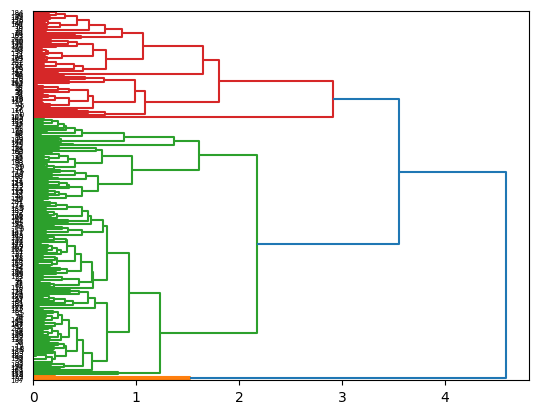

Method:  weighted


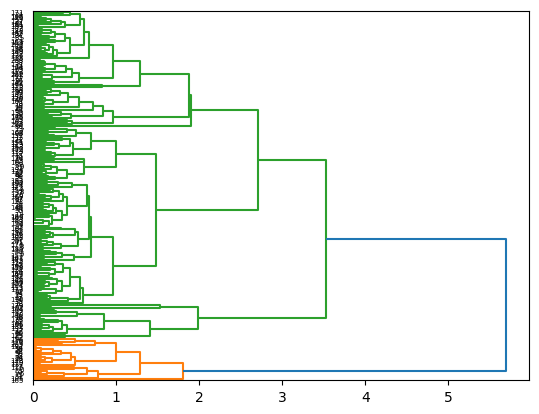

Method:  centroid


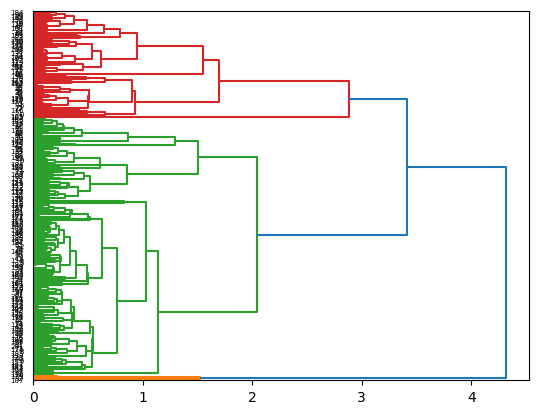

Method:  ward


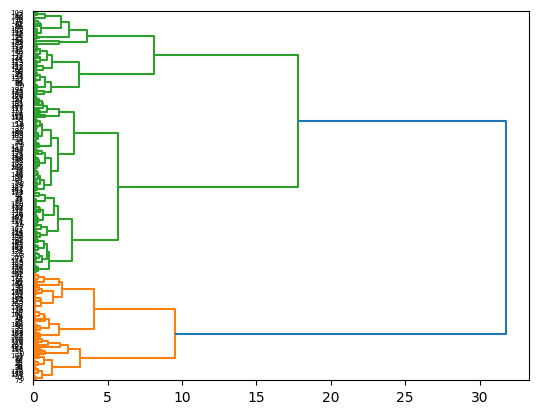

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

methods = ['single', 'complete', 'average', 'weighted', 'centroid','ward']
for method in methods:
    print("Method: ",method)
    linkage_data = linkage(df[['lifeMale', 'lifeFemale', 'infantMortality', 'GDPperCapita']],
                           method=method, metric='euclidean')
    dendrogram(linkage_data, orientation='right')
    plt.show()

Interpretation: 

### 5. EN: Create a K-Means cluster with a value of K = 4, columns: tfr, lifeMale.
### 5. ES: Crear un cluster K-Means con un valor de K = 4, columns: tfr, lifeMale.
### 5. PT: Crie um cluster K-Means com um valor de K = 4, colunas: tfr, lifeMale.

<Axes: >

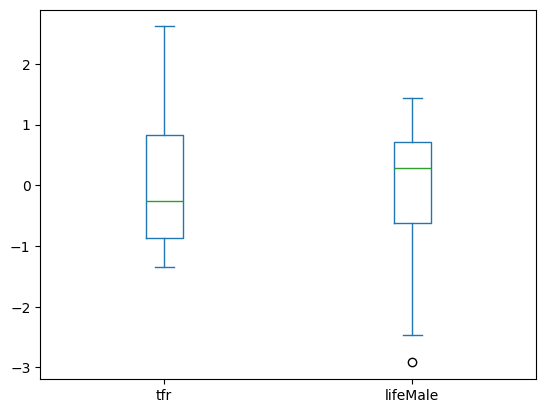

In [95]:
df[['tfr','lifeMale']].plot.box()

In [96]:
#Code
km = KMeans(4,init='k-means++', random_state=12345) # initialize the model
km.fit(df[['tfr','lifeMale']])

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,12345
,copy_x,True
,algorithm,'lloyd'


In [97]:
km.cluster_centers_  

array([[-0.21312761,  0.28062079],
       [ 1.02887683, -0.34297033],
       [-0.98073677,  0.81380917],
       [ 1.38906021, -1.74955664]])

In [98]:
df["cluster_numerico"] = km.predict(df[['tfr','lifeMale']])

In [99]:
c_map = {
    3: "A-A",    
    2: "B-A",
    1: "A-B",
    0: "M-M",
}

df['cluster_interpretacion'] = df['cluster_numerico'].map(c_map)

In [100]:
cluster_interpretacion_spain = df[df['country'] == 'Spain']['cluster_interpretacion'].values[0]

In [101]:
len(df[df['cluster_interpretacion'] == cluster_interpretacion_spain])

72

In [102]:
df[df['cluster_interpretacion'] == cluster_interpretacion_spain]

,country,region,tfr,contraception,educationMale,educationFemale,lifeMale,lifeFemale,infantMortality,GDPperCapita,economicActivityMale,economicActivityFemale,illiteracyMale,illiteracyFemale,cluster_numerico,cluster_interpretacion
8,Armenia,Europe,-1.051987,-1.138809,-0.032076,0.065576,0.359396,0.503134,-0.473950,-0.621718,-1.684716,0.325817,-0.991405,-1.089672,2,B-A
9,Australia,Oceania,-0.941351,1.592280,2.716351,2.185046,1.220666,1.172931,-0.971826,1.529404,-0.369612,0.446002,-0.327698,-0.256491,2,B-A
10,Austria,Europe,-1.215030,1.339401,1.682289,1.280103,1.042110,1.070601,-0.971826,2.508180,-1.027164,0.038707,-0.327698,-0.256491,2,B-A
12,Bahamas,America,-0.906413,0.884220,0.430530,0.803818,0.706004,0.791519,-0.762194,0.710007,0.682470,1.327362,-0.915762,-1.025908,2,B-A
15,Barbados,America,-1.034518,0.530190,-0.032076,0.065576,1.031607,0.940363,-0.893214,0.123179,-0.457286,0.953452,-0.884244,-0.974897,2,B-A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,Ukraine,Europe,-1.238322,-1.088233,-0.032076,0.065576,-0.018723,0.503134,-0.657378,-0.584577,-1.085613,0.666342,-0.989514,-1.019107,2,B-A
194,United.Kingdom,Europe,-1.040341,1.895734,2.607503,2.423188,1.126136,1.042693,-0.971826,1.405637,-0.676470,0.425971,-0.327698,-0.256491,2,B-A
195,United.States,America,-0.900590,1.339401,2.226532,2.232674,1.010600,1.070601,-0.945622,2.183851,-0.238102,0.813236,-0.868863,-1.016046,2,B-A
196,Uruguay,America,-0.731724,0.125584,-0.032076,0.065576,0.611475,0.698492,-0.683582,-0.048435,-0.369612,-0.028063,-0.814904,-1.013156,2,B-A


### 6. ES: draw the __elbow curve__ and determine the number of Clusters for K-Means using this rule and the columns: lifeMale, lifeFemale, infantMortality and GDPperCapita, how many clusters should we do?

### 6. ES: trazar la __curva del codo__ y determinar el número de Cluster para K-Means utilizando dicha regla y las columnas: lifeMale, lifeFemale, infantMortality y GDPperCapita, ¿cuantos clusters debemos hacer?

### 6. PT: desenhe a __curva do cotovelo__ e determine o número de Clusters para K-Means usando esta regra e as colunas: lifeMale, lifeFemale, infantMortality e GDPperCapita, quantos clusters devemos fazer?

In [105]:
df2 = df[["lifeMale", "lifeFemale", "infantMortality", "GDPperCapita"]]

In [106]:
K = range(1,10)

# scipy.cluster.vq.kmeans
k_clusters = [kmeans(df2.values,k) for k in K] # apply kmeans 1 to 10
k_clusters[:3]

[(array([[-2.89623398e-17,  2.89623398e-17,  3.32530568e-17,
           3.16440379e-17]]),
  np.float64(1.7195698188358344)),
 (array([[ 0.55488555,  0.57170226, -0.5530968 ,  0.23070788],
         [-1.35946959, -1.40067054,  1.35508716, -0.56523431]]),
  np.float64(1.0803506997966137)),
 (array([[-1.38094795, -1.41890548,  1.36432517, -0.56455468],
         [ 0.38618378,  0.41527024, -0.42635023, -0.35282907],
         [ 1.00979223,  0.98592223, -0.87238486,  1.84018191]]),
  np.float64(0.7575877811604163))]

In [107]:
euclidean_centroid = [cdist(df2.values, centroid, 'euclidean') for (centroid,var) in k_clusters]
print ('-----with 1 cluster------')
print (euclidean_centroid[0][:5])

print ('-----with 2 cluster------')
print (euclidean_centroid[1][:5])


-----with 1 cluster------
[[4.10802944]
 [0.92447658]
 [0.64948475]
 [1.13532832]
 [0.72533644]]
-----with 2 cluster------
[[5.08309048 1.8220991 ]
 [0.84911635 3.09562941]
 [1.02673486 2.69691759]
 [0.77896699 3.37062529]
 [0.81236407 2.93241359]]


In [108]:
distance = [np.min(D,axis=1) for D in euclidean_centroid]
print ('-----with 1st cluster------')
print (distance[0][:5])
print ('-----with 2nd cluster------')
print (distance[1][:5])

-----with 1st cluster------
[4.10802944 0.92447658 0.64948475 1.13532832 0.72533644]
-----with 2nd cluster------
[1.8220991  0.84911635 1.02673486 0.77896699 0.81236407]


In [109]:
avgWithinSumSquare = [sum(d)/df2.values.shape[0] for d in distance]
avgWithinSumSquare

[np.float64(1.7195698188358333),
 np.float64(1.0803506997966141),
 np.float64(0.7575877811604163),
 np.float64(0.6538209200640328),
 np.float64(0.5722558240229858),
 np.float64(0.5096831718170408),
 np.float64(0.4731200970435397),
 np.float64(0.45051617799711496),
 np.float64(0.4291740131076211)]

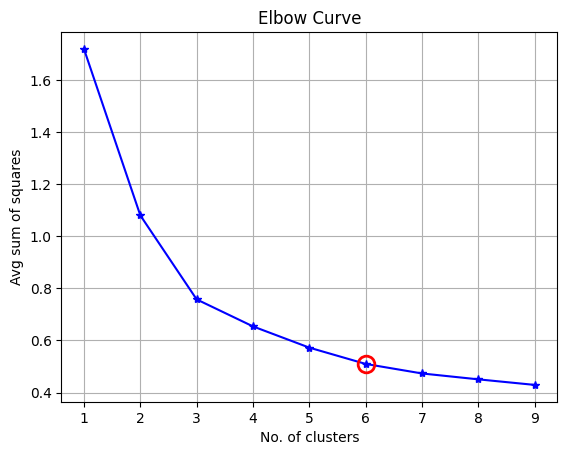

In [110]:
point_id = 5
# plot elbow curve
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(K, avgWithinSumSquare, 'b*-')
ax.plot(K[point_id], avgWithinSumSquare[point_id], marker='o', markersize=12, 
      markeredgewidth=2, markeredgecolor='r', markerfacecolor='None')
plt.grid(True)
plt.xlabel('No. of clusters')
plt.ylabel('Avg sum of squares')
tt = plt.title('Elbow Curve')

### 7. ES: Print the centroids for a Kmeans with 3 clusters for the datasets/UN.csv using only columns 'tfr', 'lifeMale' and random_state=12345

### 7. ES: Imprima los centroides para un Kmeans con 3 clústeres para los conjuntos de datos/UN.csv usando solo las columnas 'tfr', 'lifeMale' y random_state=12345

### 7. PT: Imprima os centróides para um Kmeans com 3 clusters para os conjuntos de dados/UN.csv usando apenas as colunas 'tfr', 'lifeMale' e random_state=12345

In [117]:
km = KMeans(6,init='k-means++', random_state=12345) # initialize the model
km.fit(df2)

,n_clusters,6
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,12345
,copy_x,True
,algorithm,'lloyd'


In [122]:
km.cluster_centers_  

array([[ 4.89811525e-01,  5.53523959e-01, -6.30737207e-01,
        -3.65488290e-01,  1.33226763e-15],
       [ 1.17819632e-01,  9.85814632e-02, -1.73458903e-02,
        -4.87821620e-01,  5.00000000e+00],
       [-9.87727771e-01, -1.06849646e+00,  8.87159080e-01,
        -5.34405156e-01,  3.00000000e+00],
       [-1.95439403e+00, -1.92991863e+00,  2.06019238e+00,
        -6.08522746e-01,  1.00000000e+00],
       [ 9.73657533e-01,  9.48382282e-01, -8.63395350e-01,
         8.73273419e-01,  4.00000000e+00],
       [ 1.00728334e+00,  1.00303374e+00, -8.90455350e-01,
         2.60136629e+00,  2.00000000e+00]])

In [124]:
df["cluster_numerico_expandido"] = km.predict(df2)
df

,country,region,tfr,contraception,educationMale,educationFemale,lifeMale,lifeFemale,infantMortality,GDPperCapita,economicActivityMale,economicActivityFemale,illiteracyMale,illiteracyFemale,cluster_numerico,cluster_interpretacion,cluster_numerico_expandido
0,Afghanistan,Asia,1.975954,0.125584,-0.032076,0.065576,-1.972337,-2.101632,2.906362,-0.349277,1.603042,-2.665466,2.317990,2.502358,3,A-A,3
1,Albania,Europe,-0.527921,0.125584,-0.032076,0.065576,0.443422,0.503134,-0.290522,-0.566115,0.039531,0.085446,-0.327698,-0.256491,0,M-M,0
2,Algeria,Africa,0.176658,0.378463,-0.113713,-0.767924,0.390905,0.158933,0.023925,-0.493144,-0.018918,-2.625404,0.634926,1.057044,1,M-M,1
3,American.Samoa,Asia,-0.254241,0.125584,-0.032076,0.065576,0.443422,0.410107,-0.840806,-0.466053,-2.590676,-0.315172,-0.993675,-1.095624,0,M-M,0
4,Andorra,Europe,-0.254241,0.125584,-0.032076,0.065576,0.285872,0.331034,-0.342930,-0.466053,0.039531,0.085446,-0.327698,-0.256491,0,M-M,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,Western.Sahara,Africa,0.275648,0.125584,-0.032076,0.065576,-0.417849,-0.510864,0.548005,-0.466053,0.039531,0.085446,-0.327698,-0.256491,2,A-B,2
203,Yemen,Asia,2.383561,-1.897444,-0.032076,0.065576,-0.669928,-0.948092,0.967268,-0.580426,0.594797,-3.019345,1.032432,1.845675,2,A-B,2
204,Yugoslavia,Europe,-0.993758,0.125584,-0.032076,0.065576,0.632481,0.624070,-0.631174,-0.497951,0.039531,0.085446,-0.897986,-0.725283,0,B-A,0
205,Zambia,Africa,1.154916,-0.987081,-1.855290,-2.244409,-2.266430,-2.315595,1.569960,-0.618659,0.039531,0.085446,-0.102596,0.109088,3,A-A,3


In [126]:
cluster_numerico_expandido = df[df['country'] == 'Spain']['cluster_numerico_expandido'].values[0]
cluster_numerico_expandido

np.int32(4)

In [128]:
len(df[df['cluster_numerico_expandido'] == 4])

29

In [131]:
df[df['cluster_numerico_expandido'] == 4]["country"].values

array(['Australia', 'Bahamas', 'Bahrain', 'Barbados', 'Brunei', 'Canada',
       'Cyprus', 'French.Polynesia', 'Greece', 'Guadeloupe', 'Ireland',
       'Israel', 'Italy', 'Korea.Republic.of', 'Kuwait', 'Malta',
       'Martinique', 'Netherlands.Antilles', 'New.Caledonia',
       'New.Zealand', 'Portugal', 'Puerto.Rico', 'Qatar', 'Reunion',
       'San.Marino', 'Slovenia', 'Spain', 'United.Arab.Emirates',
       'United.Kingdom'], dtype=object)